In [46]:
%load_ext autoreload
%autoreload 2
import helper_functions as hf
from imports import *
import importlib

num_available_cpus = multiprocessing.cpu_count()
print("Number of available CPUs:", num_available_cpus)

torch.cuda.empty_cache()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device =", device)
torch.set_default_tensor_type('torch.cuda.FloatTensor') if torch.cuda.is_available() else print ('cpu')

torch.set_num_threads(num_available_cpus)

print("Number of threads:", torch.get_num_threads())
print("Number of interop threads:", torch.get_num_interop_threads())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Number of available CPUs: 80
Device = cuda:0
Number of threads: 80
Number of interop threads: 80


# Function to construct quak spaces

In [107]:
def makeQuakSpace(bkg_axes,sig_axes,baseDir):
    from sklearn.decomposition import PCA
    
    axes = sig_axes+bkg_axes
    spaceName = "-".join(bkg_axes+sig_axes)
    if not os.path.isdir(baseDir+"/quakSpaces/"+spaceName):
        os.mkdir(baseDir+"/quakSpaces/"+spaceName)
    outDir = baseDir+"/quakSpaces/"+spaceName+"/"
    
    # loading some bkg files for the PCA
    data_dict = {axName:[] for axName in axes}
    masses = []
    for i in range(3):
        fName = baseDir+"/nominal/eval_QCDBKG_{0}.h5".format(i)
        with h5py.File(fName,"r") as f:
            for axName in axes:
                data_dict[axName].append(f[axName][()])
            masses.append(f["mass"][()])
    data_dict = {axName:np.concatenate(data_dict[axName],axis=0) for axName in list(data_dict.keys())}
    masses = np.concatenate(masses,axis=0)
    combined = [masses[:,np.newaxis]] + [data_dict[axName][:,np.newaxis] for axName in axes]
    combined = np.concatenate(combined,axis=1)
    
    #variance = np.std(combined,axis=0)
    #order = np.argsort(variance)[::-1]
    #print("Variance-ordered axes are {0}".format(np.array((['mass']+axes))[order]))
    #combined = combined[:,order]
    #axesWithMass = ['mass'] + axes
    #axesWithMass = np.array(axesWithMass)[order]
    
    
    # doing the PCA
    pcas = {}
    for axName in axes:
        pca = PCA()
        toFit = np.concatenate((masses[:,np.newaxis],data_dict[axName][:,np.newaxis]),axis=1)
        pca = pca.fit(toFit)
        pcas[axName] = pca
    #pca = PCA()
    #pca = pca.fit(combined)
    
    # cleanup
    del data_dict, masses, combined
    
    # apply PCA to all the files
    for file in [ff for ff in os.listdir(baseDir+"/nominal/") if ".h5" in ff]:
        fName = baseDir+"/nominal/"+file
        with h5py.File(fName,"r") as f:
            mass = f["mass"][()][:,np.newaxis]
            transformed_dict = {}
            for axName in axes:
                toTransform = np.concatenate((mass,f[axName][()][:,np.newaxis]),axis=1)
                pca = pcas[axName]
                transformed = np.dot(toTransform,pca.components_.T)
                transformed_dict[axName] = transformed[:,1]
            #combined = [f[axName][()][:,np.newaxis] for axName in axesWithMass]
            #combined = np.concatenate(combined,axis=1)
            #transformed = pca.transform(combined)
            with h5py.File(outDir+file,"w") as of:
                of.create_dataset("mass",data=mass)
                #for i in range(len(axesWithMass)):
                #    if axesWithMass[i] != "mass":
                #        of.create_dataset(axesWithMass[i],data=transformed[:,i])
                for axName in axes:
                    of.create_dataset(axName,data=transformed_dict[axName])
    return outDir

In [118]:
import corner
import matplotlib.lines as mlines
import matplotlib as mpl
def makeCornerPlots(directory,bkg_axes,sig_axes,sigs,nBins=50,lossCut=100,quantile=0.01):
    axes = bkg_axes+sig_axes
    bkg_data = []
    for i in range(3):
        with h5py.File(outDir+"eval_QCDBKG_{0}.h5".format(i),"r") as f:
            data = []
            for ax in axes:
                data.append(f[ax][()][:,np.newaxis])
            data = np.concatenate(data,axis=1)
            data = data[np.all(np.abs(data) < lossCut,axis=1)]
            bkg_data.append(data)
    bkg_data = np.concatenate(bkg_data,axis=0)
    
    sig_data = []
    for sig in sigs:
        with h5py.File(outDir+"eval_{0}.h5".format(sig),"r") as f:
            data = []
            for ax in axes:
                data.append(f[ax][()][:,np.newaxis])
            data = np.concatenate(data,axis=1)
            data = data[np.all(np.abs(data) < lossCut,axis=1)]
            sig_data.append(data)
    
    datas = [bkg_data] + sig_data
    leftLims, rightLims = [],[]
    for dat in datas:
        leftLims.append(np.quantile(dat,quantile/2,axis=0).reshape(1,-1))
        rightLims.append(np.quantile(dat,1-quantile/2,axis=0).reshape(1,-1))
    leftLims = np.concatenate(leftLims,axis=0)
    rightLims = np.concatenate(rightLims,axis=0)
    leftLims = np.min(leftLims,axis=0)
    rightLims = np.max(rightLims,axis=0)
    lossRanges = [[leftLims[i],rightLims[i]] for i in range(len(leftLims))]
    print(lossRanges)
    labels = ["QCDBKG"] + sigs
    fig = plt.figure(figsize=(10,10))
    lines = []
    for i,d in enumerate(datas):
        b = corner.corner(
            datas[i],
            quantiles=[0.99],
            fig=fig,
            color='C{0}'.format(i),
            hist_kwargs={'density':True},
            contour_kwargs={"levels":[20]},
            labels=axes,
            label_kwargs={'fontsize':14},
            bins=[nBins for i in range(len(axes))],
            plot_datapoints=False,
            plot_density=True,
            fill_contours=False,
            no_fill_contours=True,
            range=lossRanges,
            data_kwargs={"alpha":0.5}
        )
        lines.append(mlines.Line2D([], [], color='C{0}'.format(i), label=labels[i]))
    plt.legend(handles=lines,loc=4,bbox_to_anchor=(0., 1.0, 1., .0))

# Making dataSB-training quak spaces (2017)

In [119]:
year = 2017
baseDir="evaluations/dataSB/{0}".format(year)
Path(baseDir+"/quakSpaces").mkdir(exist_ok=True)

[[-2.296885471343994, 47.659309329985994], [1.0970756179094314, 90.39667915344221]]


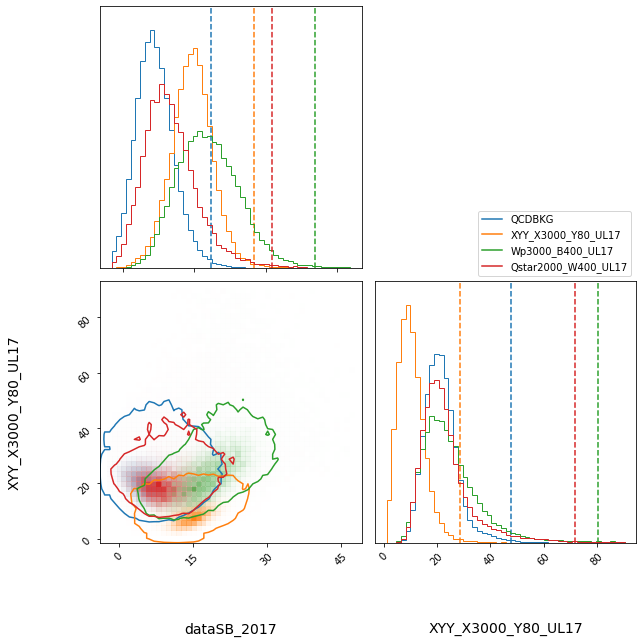

In [120]:
sig_axes = ['XYY_X3000_Y80_UL17']
bkg_axes = ['dataSB_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[-2.298854422569275, 74.44565979003902], [3.090518584251404, 91.57769027709963]]


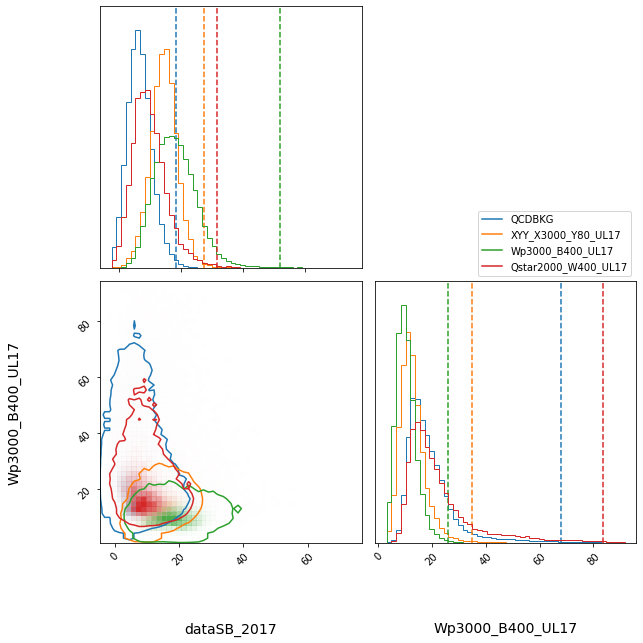

In [121]:
sig_axes = ['Wp3000_B400_UL17']
bkg_axes = ['dataSB_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[-2.296830394268036, 63.40726110458375], [6.4028882837295535, 59.921782646179295]]


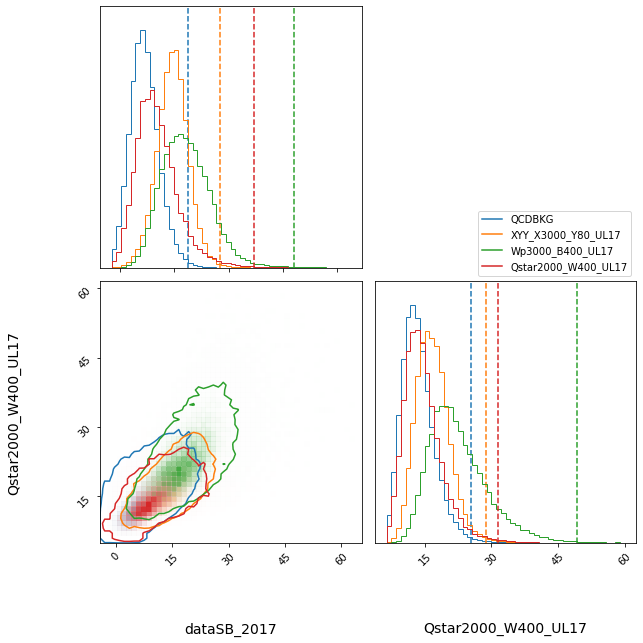

In [122]:
sig_axes = ['Qstar2000_W400_UL17']
bkg_axes = ['dataSB_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[-2.299393653869629, 47.66041934967086], [1.0959507429599762, 90.34411743164074], [3.077300398349762, 90.64914360046406]]


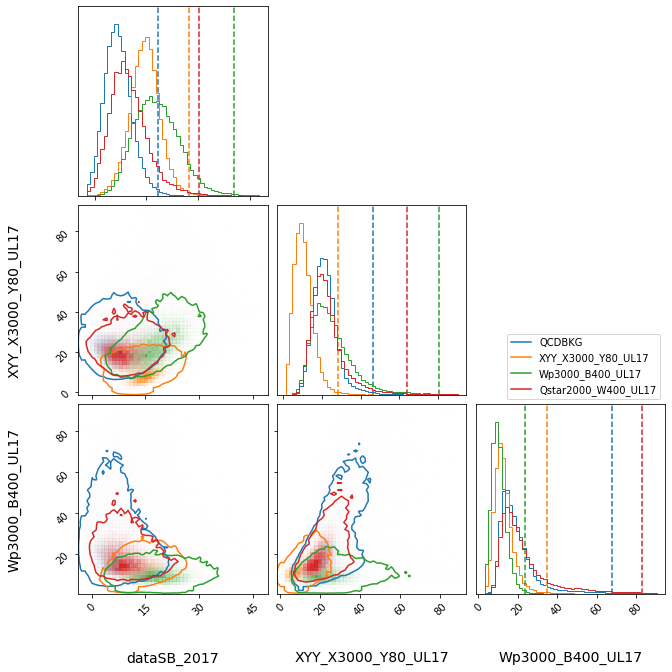

In [123]:
sig_axes = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17']
bkg_axes = ['dataSB_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[-2.296885471343994, 47.659309329985994], [1.097049458026886, 90.39667915344221], [6.40136450767517, 48.5692043685912]]


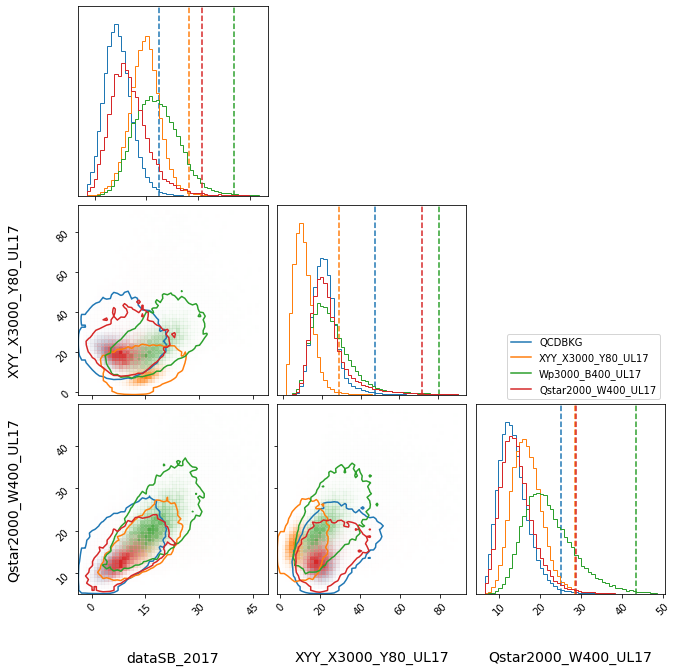

In [124]:
sig_axes = ['XYY_X3000_Y80_UL17','Qstar2000_W400_UL17']
bkg_axes = ['dataSB_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[-2.298854422569275, 63.4072919845581], [3.090412473678589, 91.57769027709963], [6.400301456451416, 59.922194290161016]]


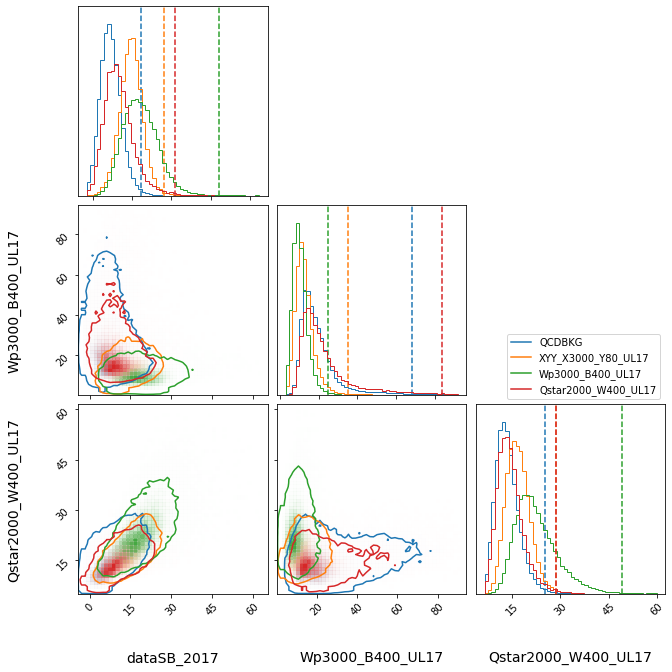

In [125]:
sig_axes = ['Wp3000_B400_UL17','Qstar2000_W400_UL17']
bkg_axes = ['dataSB_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[-2.299393653869629, 47.66041934967086], [1.095924583077431, 90.34411743164074], [3.077300398349762, 90.64914360046406], [6.400061130523682, 48.569408493042076]]


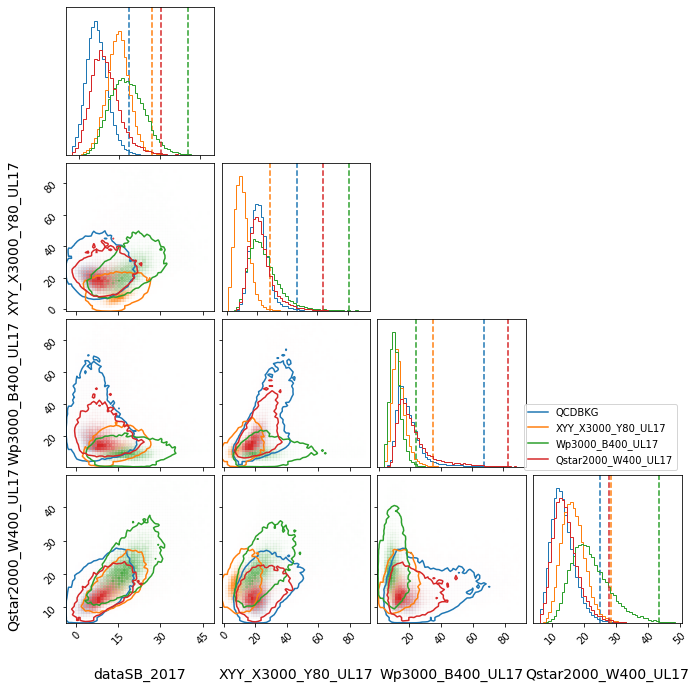

In [126]:
sig_axes = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
bkg_axes = ['dataSB_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

# Making QCDBKG (MC) quak spaces

In [127]:
year = 2017
baseDir="evaluations/qcdbkg/{0}".format(year)
Path(baseDir+"/quakSpaces").mkdir(exist_ok=True)

[[-2.25012761592865, 53.48103590011594], [-0.2078861258924007, 89.19577270507808]]


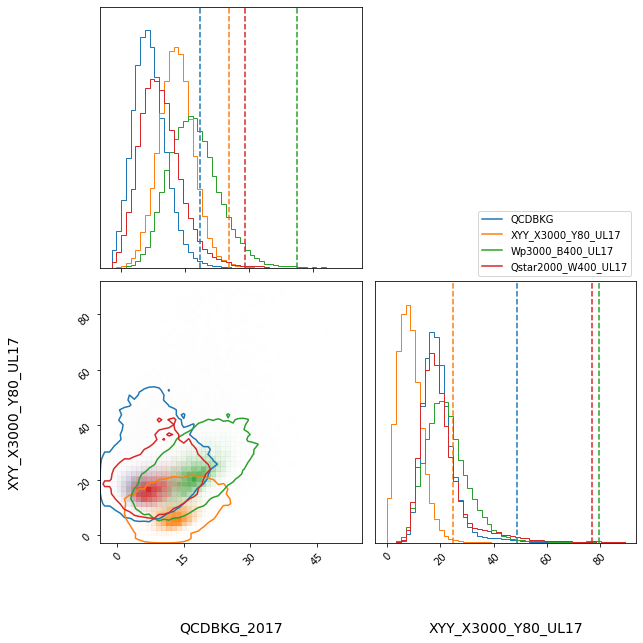

In [128]:
sig_axes = ['XYY_X3000_Y80_UL17']
bkg_axes = ['QCDBKG_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[-2.254641258716583, 66.85618877410883], [3.9599696040153503, 91.8233818817138]]


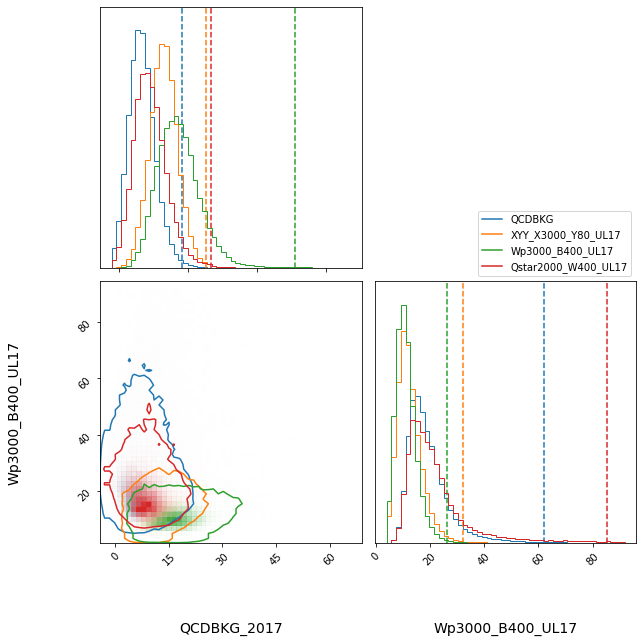

In [129]:
sig_axes = ['Wp3000_B400_UL17']
bkg_axes = ['QCDBKG_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[-2.2489438354969025, 63.04112033844006], [5.466303095817565, 72.02240715026878]]


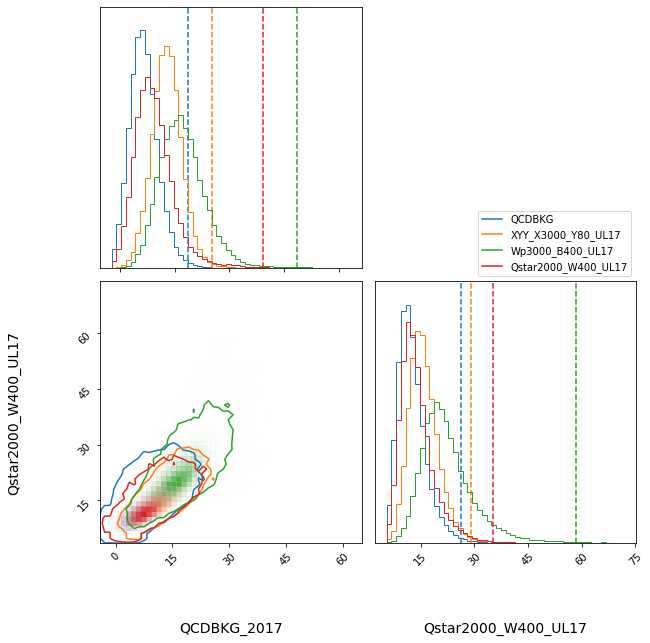

In [130]:
sig_axes = ['Qstar2000_W400_UL17']
bkg_axes = ['QCDBKG_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[-2.2550948023796082, 53.415280151367014], [-0.20870009250938887, 89.15780944824215], [3.9501539230346676, 91.58837471008296]]


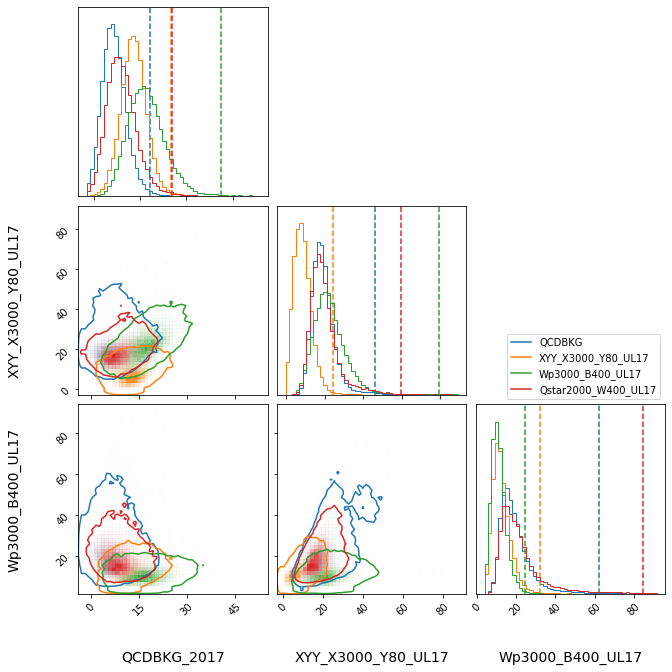

In [131]:
sig_axes = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17']
bkg_axes = ['QCDBKG_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[-2.250128935575485, 52.911645126342734], [-0.20790421403944487, 88.80025100707962], [5.4655899453163155, 61.79344291686948]]


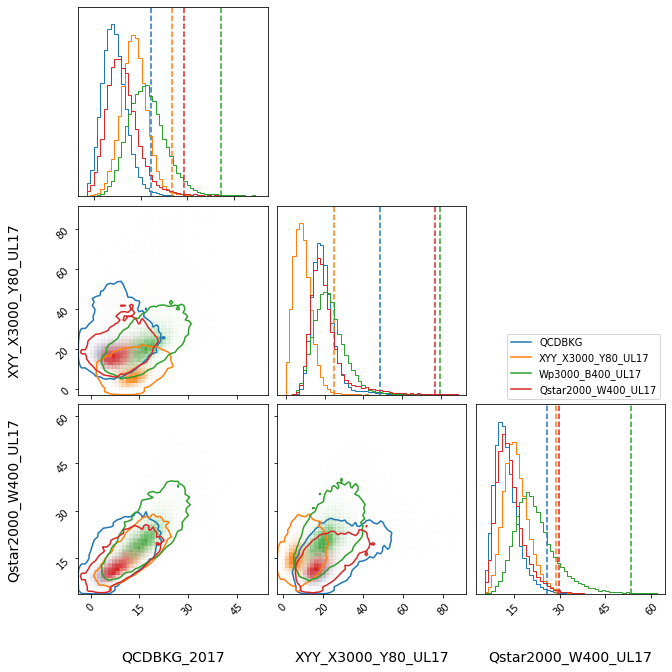

In [132]:
sig_axes = ['XYY_X3000_Y80_UL17','Qstar2000_W400_UL17']
bkg_axes = ['QCDBKG_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[-2.2546679377555847, 63.04232957839973], [3.9559083437919615, 91.82408843994148], [5.463382351398468, 72.02475124359144]]


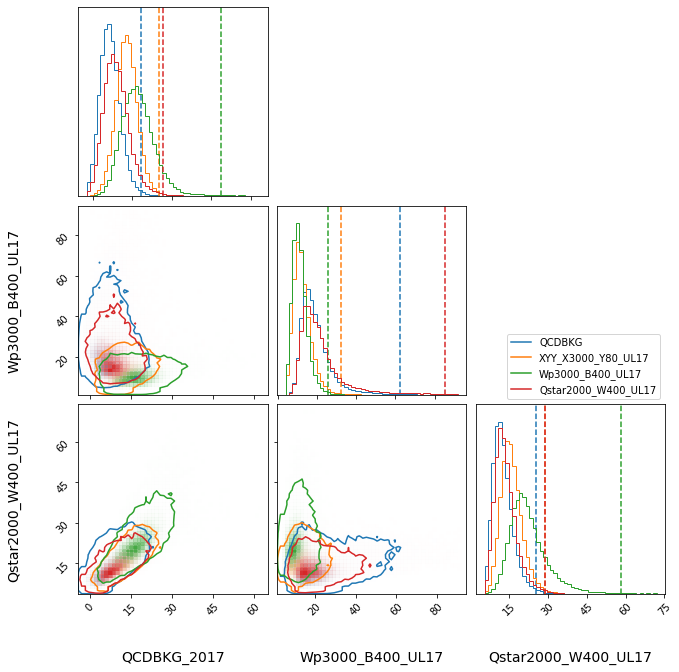

In [133]:
sig_axes = ['Wp3000_B400_UL17','Qstar2000_W400_UL17']
bkg_axes = ['QCDBKG_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[-2.2551081418991092, 52.888016090392895], [-0.20871818065643316, 88.66838245391816], [3.9499526464939114, 91.58837471008296], [5.4633773946762085, 61.79672502517624]]


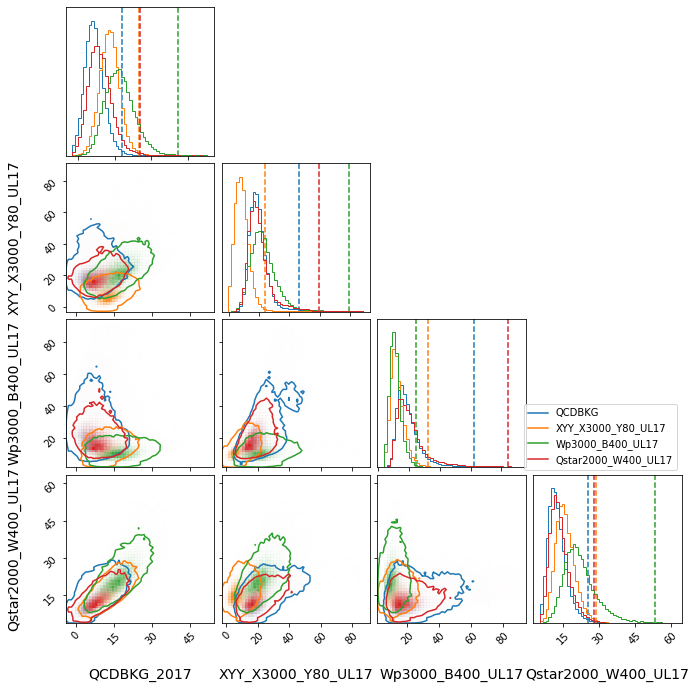

In [134]:
sig_axes = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
bkg_axes = ['QCDBKG_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

# Minor backgrounds

In [135]:
year = 2017
baseDir="evaluations/qcdbkg/{0}".format(year)
Path(baseDir+'/quakSpaces').mkdir(exist_ok=True)

[[-1.9889633572101593, 38.76090984344496], [4.634530925750733, 73.56895153045652], [0.015749196363613032, 38.0356139564511], [-0.2081031836569309, 89.01168518066416]]


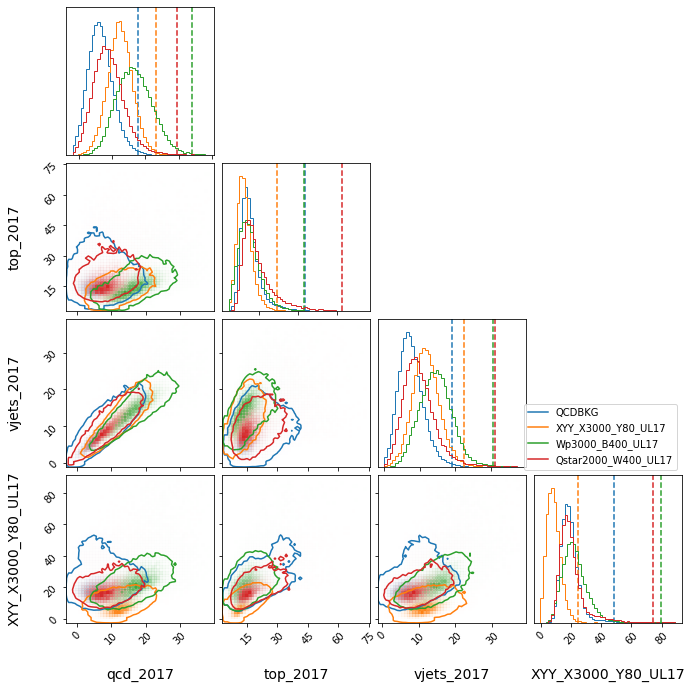

In [136]:
sig_axes = ['XYY_X3000_Y80_UL17']
bkg_axes = ['qcd_{0}'.format(year),'top_{0}'.format(year),'vjets_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[-1.9970521479845047, 47.867271671295036], [4.646884982585907, 76.12856204986551], [0.013225246337242504, 46.08777351379386], [3.957754371166229, 91.76998840332033]]


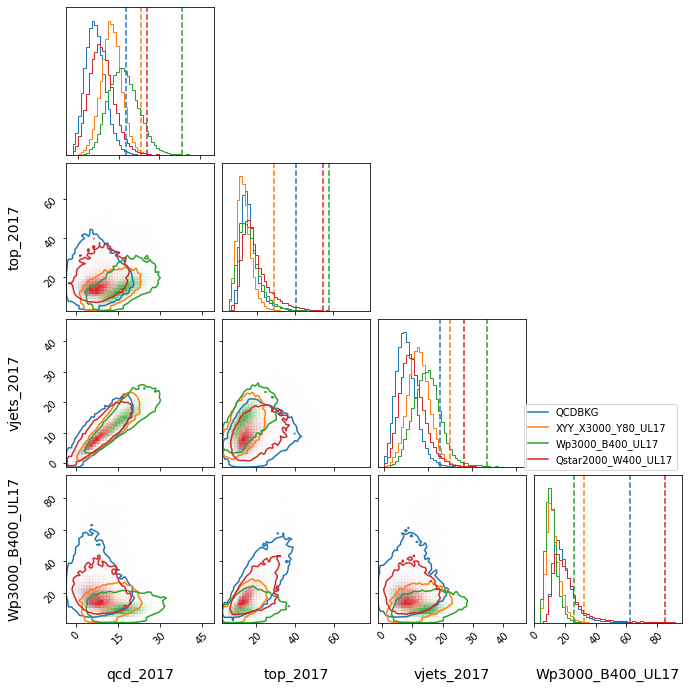

In [137]:
sig_axes = ['Wp3000_B400_UL17']
bkg_axes = ['qcd_{0}'.format(year),'top_{0}'.format(year),'vjets_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[-1.9876376014947892, 46.99281763076776], [4.643173499107361, 83.54915382385248], [0.016127864583395428, 47.66712116241416], [5.465701730251312, 70.72956863403314]]


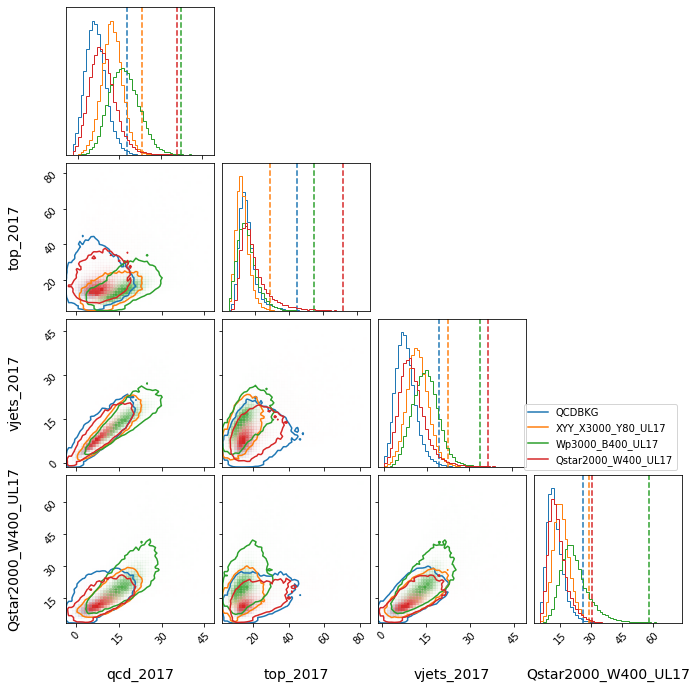

In [138]:
sig_axes = ['Qstar2000_W400_UL17']
bkg_axes = ['qcd_{0}'.format(year),'top_{0}'.format(year),'vjets_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[-1.9972784996032713, 38.685009288787874], [4.634480085372925, 59.34804580688487], [0.013056205771863429, 35.12486885070802], [-0.20886288583278656, 88.92557220458994], [3.950040158033371, 91.59039154052736]]


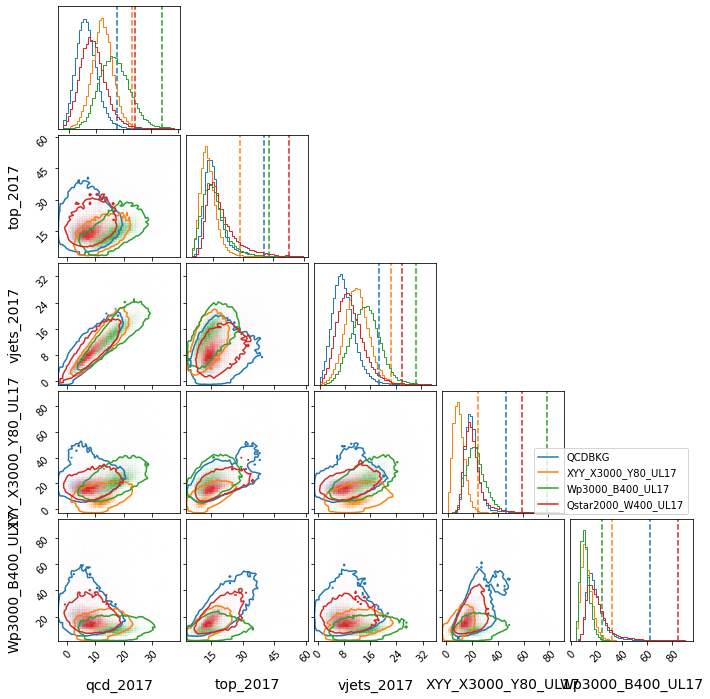

In [139]:
sig_axes = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17']
bkg_axes = ['qcd_{0}'.format(year),'top_{0}'.format(year),'vjets_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[-1.9889734774827956, 38.49745504379271], [4.6341750431060795, 73.56895153045652], [0.01574630576651546, 38.0356139564511], [-0.20812127180397508, 88.53114566802978], [5.465267741680146, 61.43363101959213]]


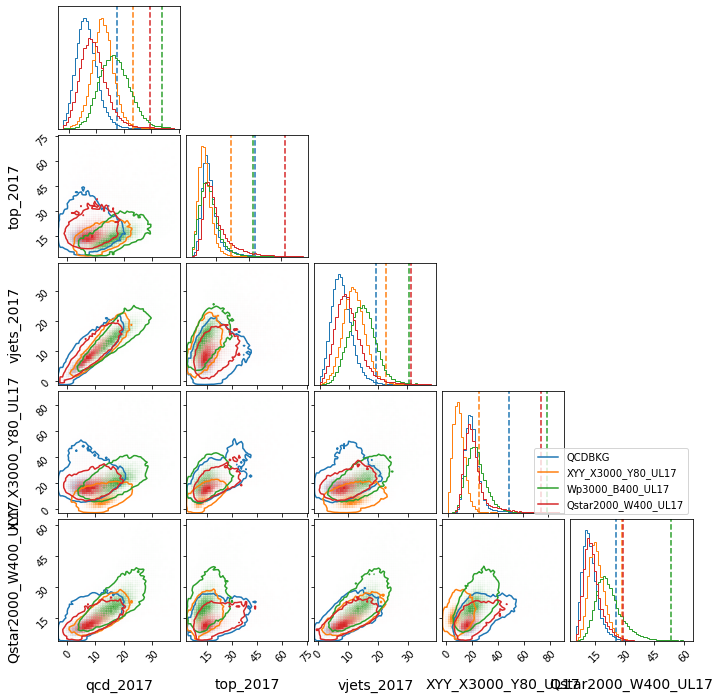

In [140]:
sig_axes = ['XYY_X3000_Y80_UL17','Qstar2000_W400_UL17']
bkg_axes = ['qcd_{0}'.format(year),'top_{0}'.format(year),'vjets_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[-1.9970677584409715, 45.397407436370756], [4.643012130260468, 71.91022014617906], [0.013213588367216247, 42.59655494689935], [3.954431521892548, 91.77021896362302], [5.463377544879913, 70.73000831603996]]


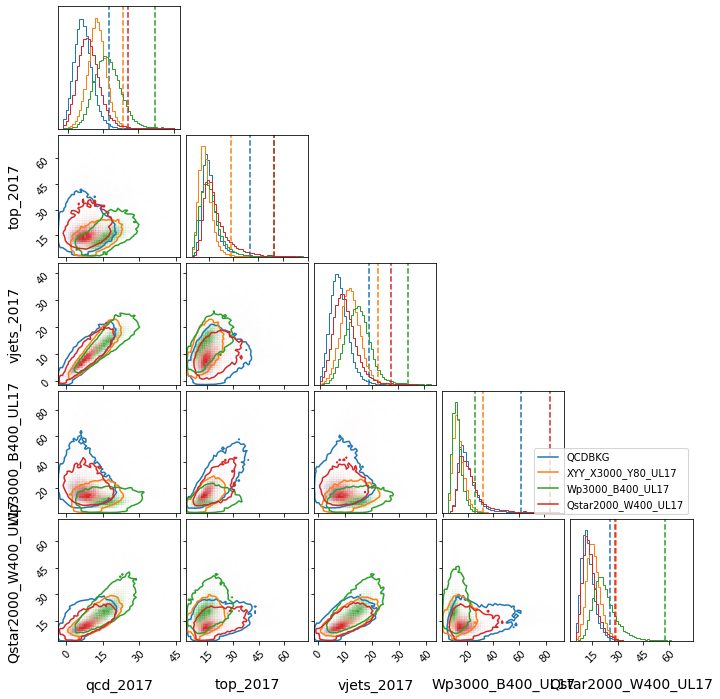

In [141]:
sig_axes = ['Wp3000_B400_UL17','Qstar2000_W400_UL17']
bkg_axes = ['qcd_{0}'.format(year),'top_{0}'.format(year),'vjets_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[-1.9972863048315048, 38.49493167877197], [4.634124202728271, 59.34804580688487], [0.013050376786850367, 34.96203834533665], [-0.20888097397983071, 88.49814865112262], [3.9498563838005065, 91.59039154052736], [5.4633733391761785, 61.43456108093242]]


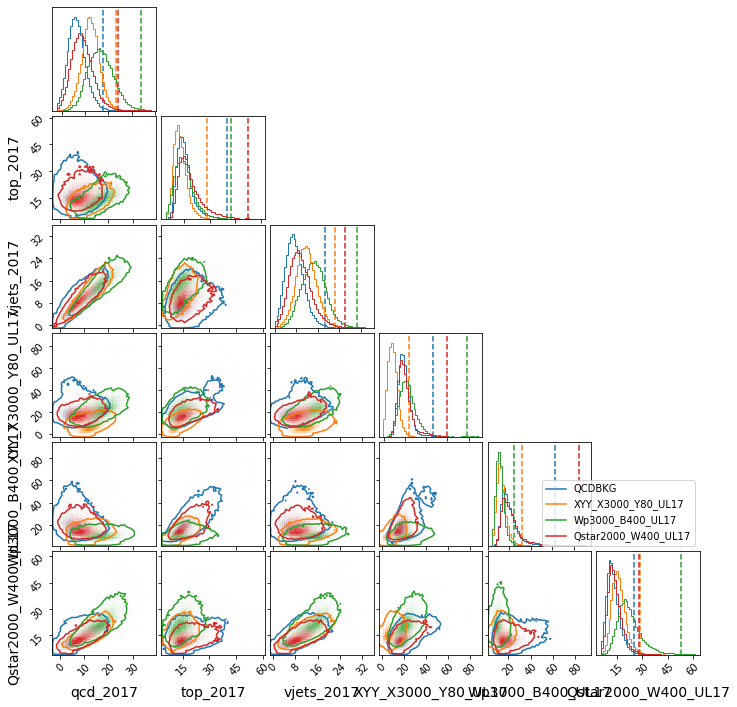

In [142]:
sig_axes = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
bkg_axes = ['qcd_{0}'.format(year),'top_{0}'.format(year),'vjets_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

# Other tests

(-30.0, 50.0)

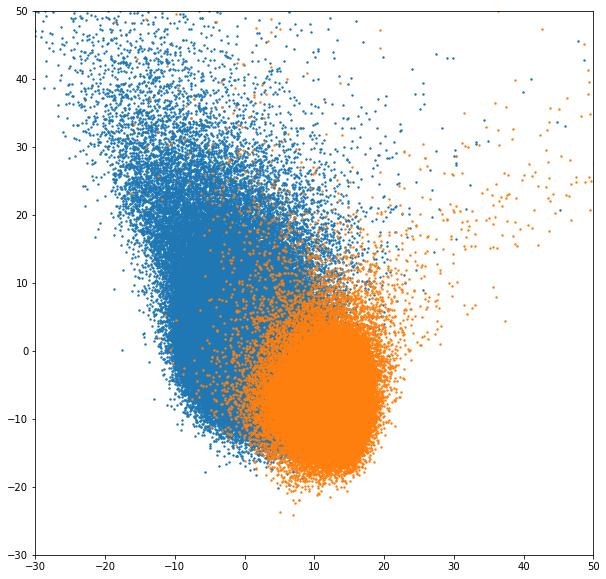

In [9]:
outDir = "evaluations/dataSB/quakSpaces/XYY"
fnb = 'evaluations/dataSB/quakSpaces/dataSB-XYY_X3000_Y80_UL17/eval_QCDBKG_15.h5'
fns = 'evaluations/dataSB/quakSpaces/dataSB-XYY_X3000_Y80_UL17/eval_XYY_X3000_Y80_UL17.h5'

fb = h5py.File(fnb,"r")
fs = h5py.File(fns,"r")

plt.figure(figsize=(10,10))
plt.scatter(fb['dataSB'][()],fb['XYY_X3000_Y80_UL17'][()],s=2)
plt.scatter(fs['dataSB'][()],fs['XYY_X3000_Y80_UL17'][()],s=2)
plt.xlim([-30,50])
plt.ylim([-30,50])

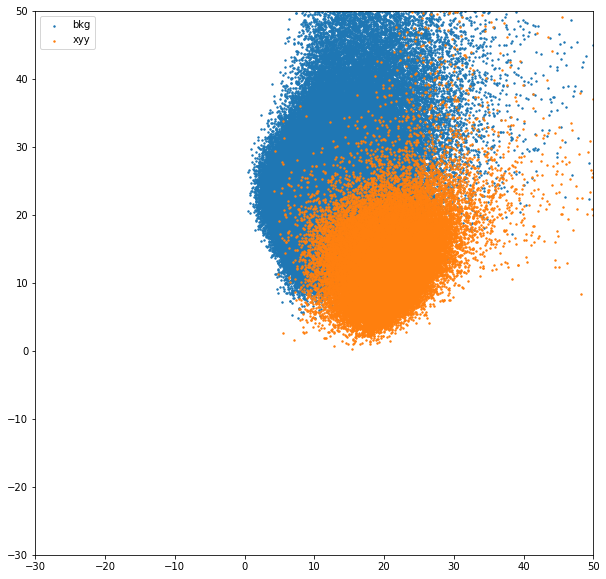

In [2]:
fnb = 'evaluations/dataSB/nominal/eval_QCDBKG_15.h5'
fns = 'evaluations/dataSB/nominal/eval_XYY_X3000_Y80_UL17.h5'

fb = h5py.File(fnb,"r")
fs = h5py.File(fns,"r")

plt.figure(figsize=(10,10))
plt.scatter(fb['dataSB'][()],fb['XYY_X3000_Y80_UL17'][()],s=2,label='bkg')
plt.scatter(fs['dataSB'][()],fs['XYY_X3000_Y80_UL17'][()],s=2,label='xyy')
plt.xlim([-30,50])
plt.ylim([-30,50])
plt.legend(loc='best')

(-30.0, 50.0)

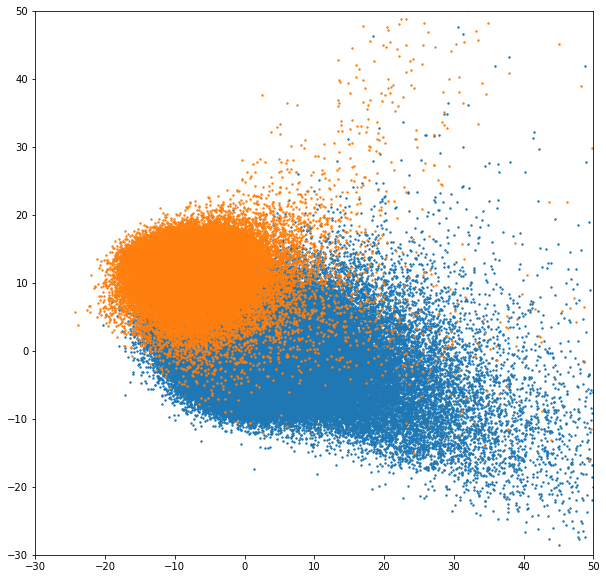

In [4]:
from sklearn.decomposition import PCA

bdat = np.concatenate([fb['mass'][()][:,np.newaxis],fb['dataSB'][()][:,np.newaxis],fb['XYY_X3000_Y80_UL17'][()][:,np.newaxis]],axis=1)
sdat = np.concatenate([fs['mass'][()][:,np.newaxis],fs['dataSB'][()][:,np.newaxis],fs['XYY_X3000_Y80_UL17'][()][:,np.newaxis]],axis=1)

pca = PCA()
pca.fit(bdat)

bt = pca.transform(bdat)
st = pca.transform(sdat)

plt.figure(figsize=(10,10))
plt.scatter(bt[:,1],bt[:,2],s=2)
plt.scatter(st[:,1],st[:,2],s=2)
plt.xlim([-30,50])
plt.ylim([-30,50])